In [33]:
# Init

from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

RANDOM_STATE = 42
VALIDATION_SIZE = 0.2
N_REPEATS = 10

DATA_DIR = Path("datasets/titanic")
OUTPUT_DIR = Path("outputs/titanic")

NUMERIC_FEATURES = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "HasCabin",
]
CATEGORICAL_FEATURES = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title"
]

In [19]:
# Load

def load_titanic_data(data_dir):
    data_dir.mkdir(parents=True, exist_ok=True)

    base_url = (
        "https://raw.githubusercontent.com/"
        "ageron/handson-ml2/master/datasets/titanic/"
    )

    for filename in ("train.csv", "test.csv"):
        path = data_dir / filename

        if not path.is_file():
            urlretrieve(base_url + filename, str(path))

    train_df = pd.read_csv(data_dir / "train.csv")
    test_df = pd.read_csv(data_dir / "test.csv")

    return train_df, test_df

train_df, test_df = load_titanic_data(DATA_DIR)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(891, 12)
(418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [20]:
# Data splitting

X_full = train_df.drop(columns="Survived")
y_full = train_df["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=VALIDATION_SIZE, stratify=y_full, random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_val.shape)

(712, 11)
(179, 11)


In [21]:
# First Analyze

X_train.info()

summary = pd.DataFrame({
    "dtype": X_train.dtypes.astype(str),
    "missing": X_train.isnull().sum(),
    "missing_fraction": X_train.isna().mean(),
    "unique_values": X_train.nunique(),
})

summary

<class 'pandas.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    str    
 3   Sex          712 non-null    str    
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    str    
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    str    
 10  Embarked     710 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 66.8 KB


,dtype,missing,missing_fraction,unique_values
PassengerId,int64,0,0.000000,712
Pclass,int64,0,0.000000,3
Name,str,0,0.000000,712
Sex,str,0,0.000000,2
Age,float64,137,0.192416,85
SibSp,int64,0,0.000000,7
Parch,int64,0,0.000000,7
Ticket,str,0,0.000000,571
Fare,float64,0,0.000000,226
Cabin,str,552,0.775281,127


In [22]:
# More Splitting

target_distribution = pd.DataFrame({
    "count": y_train.value_counts(),
    "fraction": y_train.value_counts(normalize=True),
}).sort_index()

target_distribution

,count,fraction
Survived,,
0,439,0.616573
1,273,0.383427


In [23]:
# Features

def add_features(df):
    res = df.copy()

    title = (
        res["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    )

    common_titles = ["Mr", "Miss", "Mrs", "Master"]

    res["Title"] = title.where(title.isin(common_titles), "Rare")
    res["HasCabin"] = (res["Cabin"].notna().astype(int))

    return res

add_features(X_train)[
    ["Name", "Title", "Cabin", "HasCabin"]
].head()

,Name,Title,Cabin,HasCabin
692,"Lam, Mr. Ali",Mr,NaN,0
481,"Frost, Mr. Anthony Wood 'Archie'",Mr,NaN,0
527,"Farthing, Mr. John",Mr,C95,1
855,"Aks, Mrs. Sam (Leah Rosen)",Mrs,NaN,0
801,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",Mrs,NaN,0


In [24]:
# Pipeline

def build_model(classifier):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("features", FunctionTransformer(add_features, validate=False)),
        ("preprocessing", preprocessor),
        ("classifier", clone(classifier)),
    ])

In [25]:
# CV

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

cv_splits = list(cv.split(X_train, y_train))
print(len(cv_splits))

50


In [27]:
classifiers = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "svc": SVC(random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(random_state=RANDOM_STATE),
}

cv_scores = {}
rows = []

for name, classifier in classifiers.items():
    candidate = build_model(classifier)

    scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=cv_splits,
        scoring="accuracy",
        n_jobs=-1,
        error_score="raise",
    )

    cv_scores[name] = scores

    rows.append({"model": name, "mean_accuracy": scores.mean(), "std_accuracy": scores.std()})

comparison = (pd.DataFrame(rows).set_index("model").sort_values("mean_accuracy", ascending=False))

print(comparison.round(4))

                     mean_accuracy  std_accuracy
model                                           
svc                         0.8274        0.0279
logistic_regression         0.8266        0.0322
random_forest               0.8146        0.0314
dummy                       0.6166        0.0027


In [29]:
# Searching for Parameters

selected_name = (comparison.drop(index="dummy").index[0])

parameters_grids = {
    "logistic_regression": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
    },
    "svc": {
        "classifier__C": [0.01, 0.1, 1.0, 10.0],
        "classifier__gamma": ["scale", 0.01],
        "classifier__kernel": ["rbf"],
    },
    "random_forest": {
        "classifier__max_depth": [6, None],
        "classifier__max_samples_leaf": [1, 3],
    },
}

search = GridSearchCV(
    estimator=build_model(classifiers[selected_name]),
    param_grid=parameters_grids[selected_name],
    scoring="accuracy",
    cv=cv_splits,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

search.fit(X_train, y_train)

print(selected_name)
print(search.best_params_)
print(search.best_score_)

selected_model = search.best_estimator_

svc
{'classifier__C': 10.0, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
0.8304796611838867


Validation accuracy: 0.8436
              precision    recall  f1-score   support

           0      0.853     0.900     0.876       110
           1      0.825     0.754     0.788        69

    accuracy                          0.844       179
   macro avg      0.839     0.827     0.832       179
weighted avg      0.843     0.844     0.842       179



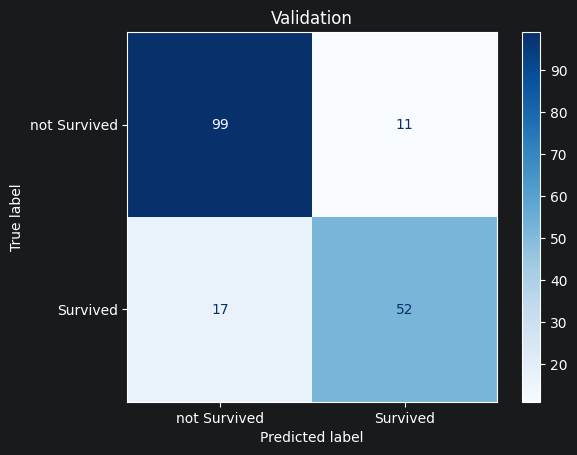

In [35]:
# Grading Model

val_predictions = selected_model.predict(X_val)

validation_accuracy = accuracy_score(y_val, val_predictions)

print(f"Validation accuracy: {validation_accuracy:.4f}")

print(classification_report(y_val, val_predictions, digits=3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_val, val_predictions, display_labels=["not Survived", "Survived"], cmap="Blues")
plt.title("Validation")
plt.show()

In [36]:
# Analyzing Model Errors

validation_details = add_features(X_val)

validation_details["actual"] = y_val
validation_details["predictions"] = val_predictions

errors = validation_details.loc[
    validation_details["actual"] != validation_details["predictions"]
].copy()

print("errors: ", len(errors))

errors[[
    "PassengerId",
    "Sex",
    "Age",
    "Pclass",
    "Title",
    "HasCabin",
    "actual",
    "predictions",
]].head(15)

errors:  28


,PassengerId,Sex,Age,Pclass,Title,HasCabin,actual,predictions
553,554,male,22.0,3,Mr,0,1,0
712,713,male,48.0,1,Mr,1,1,0
455,456,male,29.0,3,Mr,0,1,0
297,298,female,2.0,1,Miss,1,0,1
40,41,female,40.0,3,Mrs,0,0,1
564,565,female,NaN,3,Miss,0,0,1
502,503,female,NaN,3,Miss,0,0,1
17,18,male,NaN,2,Mr,0,1,0
701,702,male,35.0,1,Mr,1,1,0
447,448,male,34.0,1,Mr,0,1,0


In [37]:
# Final Model

final_model = clone(selected_model)

final_model.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7c80ddf43ce0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

In [38]:
# Predictions on test.csv

test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_predictions.astype(int),
})

assert len(submission) == len(test_df)
assert submission["PassengerId"].equals(test_df["PassengerId"])
assert submission["Survived"].isin([0, 1]).all()
assert not submission.isna().any().any()

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [39]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

submission_path = OUTPUT_DIR / "submission.csv"

submission.to_csv(OUTPUT_DIR / "model_comparison.csv")

pd.DataFrame(cv_scores).to_csv(OUTPUT_DIR / "cv_scores.csv", index=False)

print("Done")

Done


In [41]:
# Submission for Kaggle

from pathlib import Path
from sklearn.base import clone
import pandas as pd

final_model = clone(selected_model)
final_model.fit(X_full, y_full)

predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions.astype(int),
})

assert submission.shape == (418, 2)
assert not submission.isna().any().any()
assert submission["Survived"].isin([0, 1]).all()

submission_path = Path("outputs/titanic/submission.csv")
submission_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(submission_path, index=False)

print("File:", submission_path.resolve())

File: /home/kolja/home/kole4ka_bot/first-ml-project/training/titanic/outputs/titanic/submission.csv
